# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Климишин Данило'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 8     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Климишин Данило, ШІ-31, варіант 8
ваш потік:                   P>5
ваша пара для графіка 3:     швидкість вітру та густина вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
df = pd.read_excel(ФАЙЛ)
print("--- Перші 5 рядків таблиці: ---")
display(df.head())

print("\n--- Типи стовпців (dtypes): ---")
print(df.dtypes)

--- Перші 5 рядків таблиці: ---


,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN



--- Типи стовпців (dtypes): ---
Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                     

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

 * **Незрозумілий початок**: Наявність метаданих і коментарів у перших рядках файлу спричинена наявністю службової інформації на початку файлу(посилання, джерело даних, коментарі з символами # i :)

 * **Заголовки стовпців**: За замовчуванням функція pd.read_excel() вважає перший рядок таблиці назвами відповідних колонок. Оскільки перший рядок містив порожні клітинки та посилання, стовпці отримали назви "Unnamed: (номер стовпця) " і один з них отримав назву посилання.
 
 * **Тип object**: Через те, що текстові коментарі та опис потрапили в область самих даних, більшість стовпців містить суміш тексту, чисел і значень NaN. У таких випадках pandas автоматично зводить весь стовпець до узагальненого типу object.



### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
RAW = pd.read_excel(ФАЙЛ, header=None)


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
RAW = pd.read_excel(ФАЙЛ, header=None)
RAW.notna().sum()


0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

Всього є 3 таблиці

Перша таблиця займає стовпці з 2-15

Друга таблиця займає стовпці з 17-20

Третє таблиця займає стовпці з 25-32



### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
table1 = RAW.iloc[4:23, [1]].copy()

table2 = RAW.iloc[15:20, 16:17].copy()

table3 = RAW.iloc[2:8, 26:27]

combined = pd.concat([
    table1.reset_index(drop=True),
    table2.reset_index(drop=True),
    table3.reset_index(drop=True)
], axis=1)

display(combined)

#display(table1, table2, table3)




,1,16,26
0,"# Prepared by the U.S. Dept. of Commerce, NOAA...",Product: Daily Solar Data quar_DSD.txt,SOHO CELIAS Proton Monitor
1,# Please send comments and suggestions to SWPC...,:Issued: 0825 UT 04 Oct 2017,Solar Wind Parameters for Carrington Rotation ...
2,#,#,Proton speed [km/sec]
3,# Label: P > 1 = Particles at >1 Mev,"# Prepared by the U.S. Dept. of Commerce, NOA...",Proton density [protons per cubic centimeter]
4,# Label: P > 5 = Particles at >5 Mev,# Please send comments and suggestions to SWP...,NaN
5,# Label: P >10 = Particles at >10 Mev,NaN,"Measurement time (Year, Month, Day of Month, D..."
6,# Label: P >30 = Particles at >30 Mev,NaN,NaN
7,# Label: P >50 = Particles at >50 Mev,NaN,NaN
8,# Label: P>100 = Particles at >100 Mev,NaN,NaN
9,# Label: E>0.8 = Electrons at >0.8 Mev,NaN,NaN


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A |  5-minute  GOES-15 Solar Particle and Electron Flux | MeV & Protons/cm2-s-sr & Electrons/cm2-s-sr|
| B | Quarterly Daily Solar Data | solar flux units |
| C | SOHO CELIAS Proton Monitor | km/sec & protons per cubic centimeter |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
A = RAW.iloc[26:7226, 1:15]
A.columns = [
    'Year', 'Month', 'Day', 'Time_HHMM', 'Julian_day', 'Seconds',
    'P_gt_1', 'P_gt_5', 'P_gt_10', 'P_gt_30', 'P_gt_50', 'P_gt_100',
    'E_gt_08', 'E_gt_20'
]
for col in A.columns:
    A[col] = pd.to_numeric(A[col], errors='coerce')


B = RAW.iloc[27:52, 16:20]
B.columns = [
    'Year', 'Month', 'Day', 'Radio Flux 10.7'
]
for col in B.columns:
    B[col] = pd.to_numeric(B[col], errors='coerce')


C = RAW.iloc[27:628, 26:32]
C.columns = [
    'Year', 'Month', 'Day', 'Hour', 'Speed', 'Density'
]
for col in C.columns:
    C[col] = pd.to_numeric(C[col], errors='coerce')


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:


time_str_A = A['Time_HHMM'].astype(int).astype(str).str.zfill(4)

dt_str_A = (
    A['Year'].astype(int).astype(str) + '-' +
    A['Month'].astype(int).astype(str).str.zfill(2) + '-' +
    A['Day'].astype(int).astype(str).str.zfill(2) + ' ' +
    time_str_A.str[:2] + ':' + time_str_A.str[2:]
)
A['ts'] = pd.to_datetime(dt_str_A)

B['ts'] = pd.to_datetime(B[['Year', 'Month', 'Day']])

C['Year'] = C['Year'].apply(lambda y: y + 2000 if y < 100 else y)
C['ts'] = pd.to_datetime(C[['Year', 'Month', 'Day', 'Hour']])

for name, table in ('A', A) , ('B', B), ('C', C):
    print()
    print(f'{name}(min) - {table['ts'].min()}')
    print(f'{name}(max) - {table['ts'].max()}')




A(min) - 2017-08-28 00:00:00
A(max) - 2017-09-21 23:55:00

B(min) - 2017-08-28 00:00:00
B(max) - 2017-09-21 00:00:00

C(min) - 2017-08-28 00:00:00
C(max) - 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for name, table in ('A', A) , ('B', B), ('C', C):
    print(f'\n\nTable: {name}')
    print(f'Shape:  {table.shape[0]} x {table.shape[1]}')
    print('Col types:\n', table.dtypes)
    total_blanks = table.isna().sum().sum()
    print("Blanks total:", total_blanks)
    print(f'Duplicates: {table.duplicated().sum()}')
    display(table.describe())




Table: A
Shape:  7200 x 15
Col types:
 Year                   int64
Month                  int64
Day                    int64
Time_HHMM              int64
Julian_day             int64
Seconds                int64
P_gt_1               float64
P_gt_5               float64
P_gt_10              float64
P_gt_30              float64
P_gt_50              float64
P_gt_100             float64
E_gt_08              float64
E_gt_20              float64
ts            datetime64[us]
dtype: object
Blanks total: 24
Duplicates: 0


,Year,Month,Day,Time_HHMM,Julian_day,Seconds,P_gt_1,P_gt_5,P_gt_10,P_gt_30,P_gt_50,P_gt_100,E_gt_08,E_gt_20,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN




Table: B
Shape:  25 x 5
Col types:
 Year                        int64
Month                       int64
Day                         int64
Radio Flux 10.7             int64
ts                 datetime64[us]
dtype: object
Blanks total: 0
Duplicates: 0


,Year,Month,Day,Radio Flux 10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN




Table: C
Shape:  601 x 7
Col types:
 Year                int64
Month               int64
Day                 int64
Hour                int64
Speed               int64
Density           float64
ts         datetime64[us]
dtype: object
Blanks total: 0
Duplicates: 0


,Year,Month,Day,Hour,Speed,Density,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,2017.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,2017.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,2017.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,2017.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,2017.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
negative_speed = (C['Speed'] < 0).sum()
negative_density = (C['Density'] < 0).sum()

min_speed = C['Speed'].min()
avg_speed = C['Speed'].mean()
min_density = C['Density'].min()
avg_density = C['Density'].mean()


print(f'Number of negative speed elements: {negative_density}')
print(f'Number of negative density elements: {negative_density}')

print(f'Min speed: {min_speed}')
print(f'Mean speed: {avg_speed}')
print(f'Min density: {min_density}')
print(f'Mean density: {avg_density}')


C.loc[C['Speed'] < 0, 'Speed'] = np.nan
C.loc[C['Density'] < 0, 'Density'] = np.nan

min_speed_new = C['Speed'].min()
avg_speed_new = C['Speed'].mean()
min_density_new = C['Density'].min()
avg_density_new = C['Density'].mean()


print(f'\nNumber of negative speed elements after cleaning: {(C['Speed'] < 0).sum()}')
print(f'Number of negative density elements after cleaning: {(C['Density'] < 0).sum()}')

print(f'Min speed: {min_speed_new}')
print(f'Mean speed: {avg_speed_new}')
print(f'Min density: {min_density_new}')
print(f'Mean density: {avg_density_new}')



Number of negative speed elements: 8
Number of negative density elements: 8
Min speed: -1
Mean speed: 506.5474209650582
Min density: -1.0
Mean density: 2.9076539101497505

Number of negative speed elements after cleaning: 0
Number of negative density elements after cleaning: 0
Min speed: 277.0
Mean speed: 513.3946037099494
Min density: 0.1
Mean density: 2.960370994940978


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

Від'ємні значення в цих стовпцях це втрачені дані. Всього було 8 таких клітинок в стовпці з швидкістю і стільки ж в стовпці з густиною. Через те що ці дані не є дійсними, середнє значення через це ставало меншим від реального і за рахунок цього воно спотворювалось. Як можна помітити, після очистки від неправдивих даних, середнє значення трохи збільшилось.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# ВАШ КОД


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

У таблиці А є стовпці які фіксують часові позначки. У нашому випадку вимірювання відбувались циклічно з періодом в 5 секунд. Тобто всі дані які пов'язані з часом в таблиці є детерміновані і відповідно шукати середнє значення від них безглуздо. До того ж стовпець "Time_HHMM" має нелінійні позначення, після 55 хвилини іде перехід на 00, і відповідно при пошуку середнього значення можуть з'явитись значення по типу "хх68" шо насправді не має суті через те що значення хвилин може бути тільки від 00-60.


---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
flux_cols = ['P_gt_1', 'P_gt_5', 'P_gt_10', 'P_gt_30', 'P_gt_50', 'P_gt_100', 'E_gt_08', 'E_gt_20']

A_1h = (
    A[['ts'] + flux_cols]
    .set_index('ts')
    .resample('1h')
    .agg(['mean', 'max'])
)
A_1h.columns = [f'{col}_{stat}' for col, stat in A_1h.columns]

A_1h = A_1h.reset_index()

display(A_1h.head())


,ts,P_gt_1_mean,P_gt_1_max,P_gt_5_mean,P_gt_5_max,P_gt_10_mean,P_gt_10_max,P_gt_30_mean,P_gt_30_max,P_gt_50_mean,P_gt_50_max,P_gt_100_mean,P_gt_100_max,E_gt_08_mean,E_gt_08_max,E_gt_20_mean,E_gt_20_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

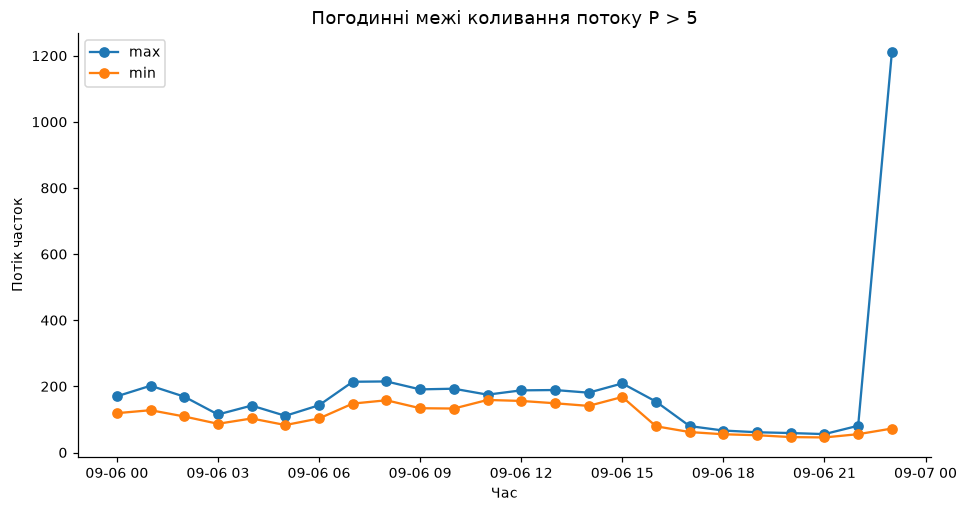

In [25]:
A_day_data = A[(A['ts'] >= '2017-09-06 00:00:00') & (A['ts'] <= '2017-09-06 23:59:00')]

max_min_agg = (
    A_day_data[['ts', 'P_gt_5']]
    .set_index('ts')
    .resample('1h')
    .agg(['max', 'min'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(max_min_agg['ts'], max_min_agg[('P_gt_5', 'max')], marker='o', label='max')
ax.plot(max_min_agg['ts'], max_min_agg[('P_gt_5', 'min')], marker='o', label='min')
ax.set_title("Погодинні межі коливання потоку P > 5", fontsize=12)
ax.set_xlabel("Час")
ax.set_ylabel("Потік часток")

ax.legend()
plt.show()


**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Що показує min: мінімальне значення потоку часток серед 12 вимірювань за цю годину. Це нижня межа.

Що показує max: максимальне значення серед тих самих 12 точок. Це верхня межа.

Спільний сенс: відстань між цими двома кривими наочно показує розкид або нестабільність сонячного потоку: Якщо лінії йдуть впритул одна до одної — процес був рівномірним і стаціонарним. Якщо лінії сильно розходяться — всередині цієї години стався різкий стрибок.

Важливість:
У спокійні дні потік частинок практично плоский і мінімальний (наприклад, фонові значення близько $0.1$–$1.0$ частинок). Лінії min і max майже зливаються в одну тонку лінію.Але якщо на Сонці стається спалах (як це було, наприклад, під час відомих спалахів X-класу у вересні 2017 року, які присутні у ваших даних): Потік високоенергетичних протонів зростає лавиноподібно — на 2–4 порядки (у 100, 1000 чи навіть 10 000 разів) лише за кілька 5-хвилинних вимірювань.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
# ВАШ КОД

B['date'] = B['ts'].dt.date
A_1h['date'] = A_1h['ts'].dt.date

C_for_merge = C[['ts', 'Speed', 'Density']]

M = pd.merge(A_1h, B[['date', 'Radio Flux 10.7']], on='date', how='left')
M = M.drop(columns=['date'])
M = pd.merge(M, C_for_merge, on='ts', how='inner')

display(M.head(5))

,ts,P_gt_1_mean,P_gt_1_max,P_gt_5_mean,P_gt_5_max,P_gt_10_mean,P_gt_10_max,P_gt_30_mean,P_gt_30_max,P_gt_50_mean,P_gt_50_max,P_gt_100_mean,P_gt_100_max,E_gt_08_mean,E_gt_08_max,E_gt_20_mean,E_gt_20_max,Radio Flux 10.7,Speed,Density
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0,82,285.0,3.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0,82,305.0,3.4
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0,82,309.0,1.7
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0,82,304.0,2.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0,82,302.0,2.3


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*


Я вибрав тип об'єднання "left". Цей тип допоможе мені з'єднати таблицю А по датам і розтягнути таблицю В так щоб не було пропусків. Цей тип дає мені 600 рядків в об'єднаній таблиці. Тип "inner" дасть мені стільки ж рядків. Тип "outer" i "right" дасть мені 601 рядок, через те що в таблиці В є на 1 запис більше ніж в таблиці А.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [58]:
A_max_1h = (
    A[['ts', 'P_gt_10']]
    .set_index('ts')
    .resample('1h')
    .agg('max')
    .reset_index()
)

conditions = [
    A_max_1h['P_gt_10'] < 10,
    (A_max_1h['P_gt_10'] >= 10) & (M['P_gt_10_max'] < 1000),
    A_max_1h['P_gt_10'] >= 1000
]

choices = ['тиха', 'активна', 'дуже активна']

M['група'] = np.select(conditions, choices, default='nan')

print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Mean value:  156.5898121843434
Median value:  0.6014166666666667


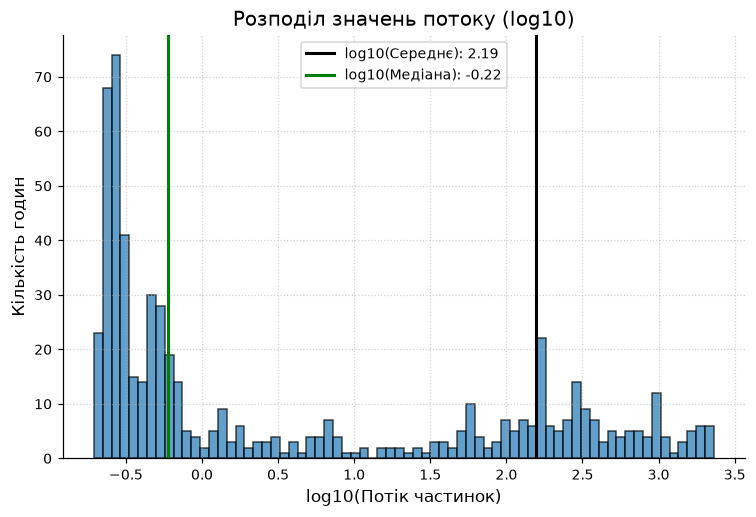

In [138]:
print('Mean value: ', M['P_gt_5_mean'].mean())
print('Median value: ', M['P_gt_5_mean'].median())
data = M['P_gt_5_mean'].dropna()
data_positive = data[data > 0]

log_data = np.log10(data_positive)

plt.figure(figsize=(8, 5))
plt.hist(log_data, bins=70, edgecolor='black', alpha=0.7)

plt.axvline(np.log10(data.mean()), color ='black', linewidth=2, 
            label=f'log10(Середнє): {np.log10(data.mean()):.2f}')
plt.axvline(np.log10(data.median()), color='green', linestyle='-', linewidth=2, 
            label=f'log10(Медіана): {np.log10(data.median()):.2f}')

plt.title('Розподіл значень потоку (log10)', fontsize=13)
plt.xlabel('log10(Потік частинок)', fontsize=11)
plt.ylabel('Кількість годин', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()




**Висновок:**
З графіку можна зробити висновок що переважну більшість часу активність залишається низькою, в районі від 0.1 до 1 частинок за годину.

Різниця між середнім значенням і медіаною пов'язана з наявністю рідкісних але великих за значенням викидів, які значним чином впливають на середнє значення. В свою чергу через те що ці випадки є поодинокі, вони ніяким чином не впливають на медіану, звідси і такий розрив.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

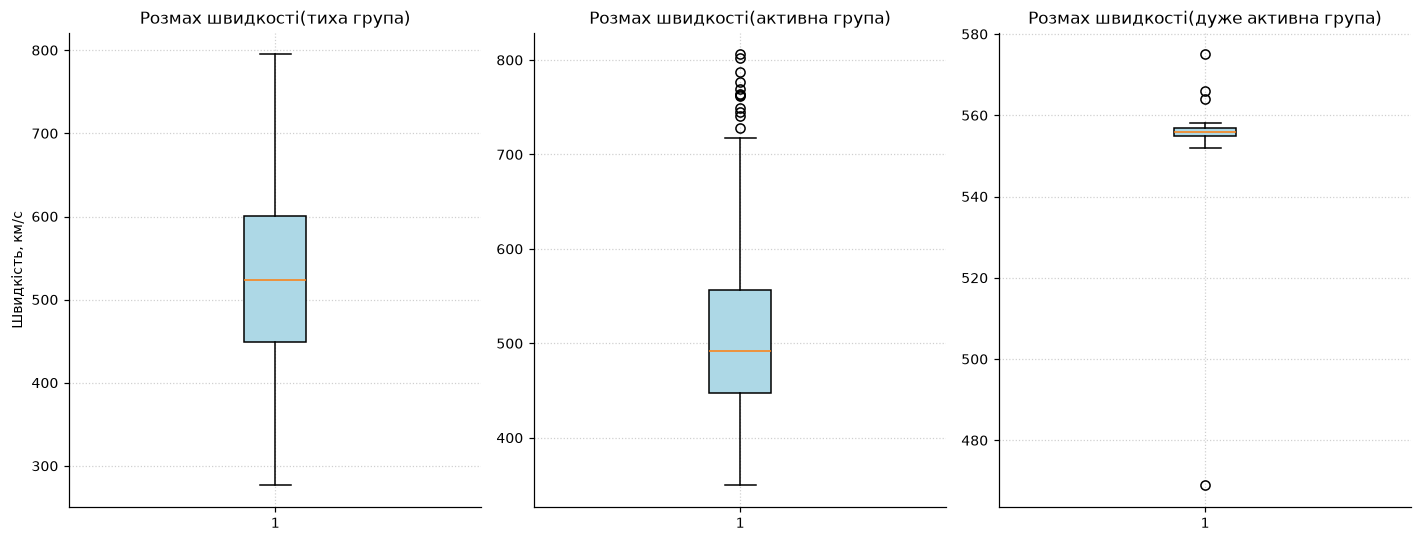

In [93]:
quiet_group = M[M['група'] == 'тиха']
active_group = M[M['група'] == 'активна']
very_active_group = M[M['група'] == 'дуже активна']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5))

# Перший графік (тиха група)
ax1.boxplot(quiet_group['Speed'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax1.set_title('Розмах швидкості(тиха група)')
ax1.set_ylabel('Швидкість, км/с')
ax1.grid(True, linestyle=':', alpha=0.6)

# Другий графік (активна група)
ax2.boxplot(active_group['Speed'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax2.set_title('Розмах швидкості(активна група)')
ax1.set_ylabel('Швидкість, км/с')
ax2.grid(True, linestyle=':', alpha=0.6)

# Третій графік (дуже активна група)
ax3.boxplot(very_active_group['Speed'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax3.set_title('Розмах швидкості(дуже активна група)')
ax1.set_ylabel('Швидкість, км/с')
ax3.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


**Висновок:**

На діаграмі розмаху тихої групи можна побачити досить розкиданий розподіл значень, з медіаною приблизно посередині, досить широким ящиком, і досить широкими вусами, але більшість значень входять в ці рамки.

На діаграмі розмаху активної групи ящик зміщений ближче до нижньої межі. Медіана теж зміщена вниз. Верхній вус значно більший за нижній і досить велика частина значень виходить за межі верхнього вусу.

На діаграмі розмаху дуже активної групи ящик дуже вузький і знаходиться в верхній частині графіка. Вуса досить короткі. Незначна частина значень досить сильно розкидана по графіку, поза межами ящика.


### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

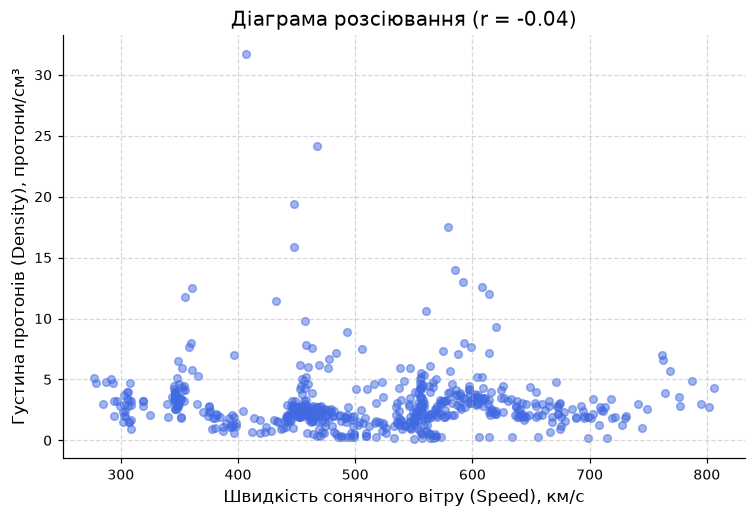

In [98]:
corr_value = M['Speed'].corr(M['Density'])

plt.figure(figsize=(8, 5))

plt.scatter(M['Speed'], M['Density'], alpha=0.5, color='royalblue', s=25)

plt.title(f"Діаграма розсіювання (r = {corr_value:.2f})", fontsize=13)
plt.xlabel("Швидкість сонячного вітру (Speed), км/с", fontsize=11)
plt.ylabel("Густина протонів (Density), протони/см³", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()



**Висновок:**

Кореляція Пірсона в мене вийшла -0.04, тобто кореляція практично відсутня, з графіка це теж видно.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

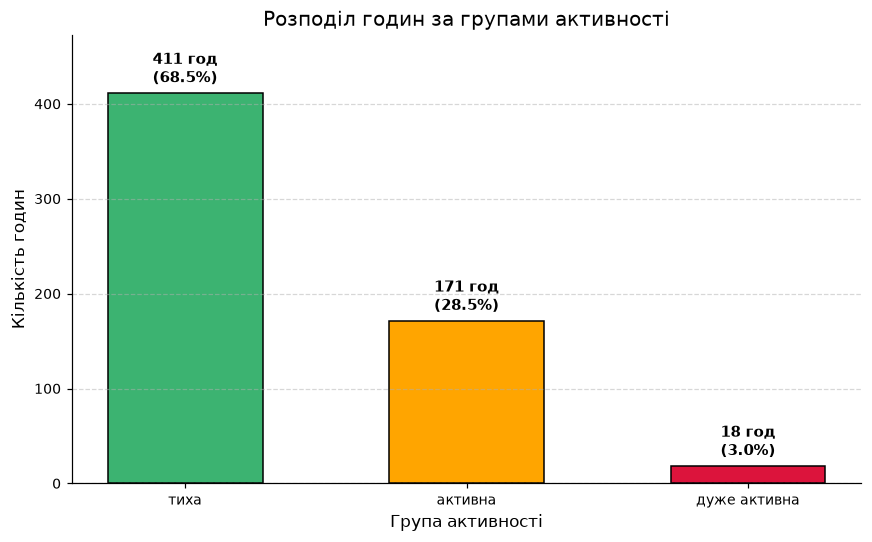

In [103]:
order = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts()[order]
total_hours = len(M) 

labels = [f"{count} год\n({(count / total_hours) * 100:.1f}%)" for count in counts]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=['mediumseagreen', 'orange', 'crimson'], edgecolor='black', width=0.55)

ax.bar_label(bars, labels=labels, padding=4, fontsize=10, fontweight='bold')

ax.set_title('Розподіл годин за групами активності', fontsize=13)
ax.set_xlabel('Група активності', fontsize=11)
ax.set_ylabel('Кількість годин', fontsize=11)
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Висновок:**

Більшість годин(68.5%) приходиться на тиху групу. Незначна частина годин приходиться на дуже активну групу, всього 3%.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

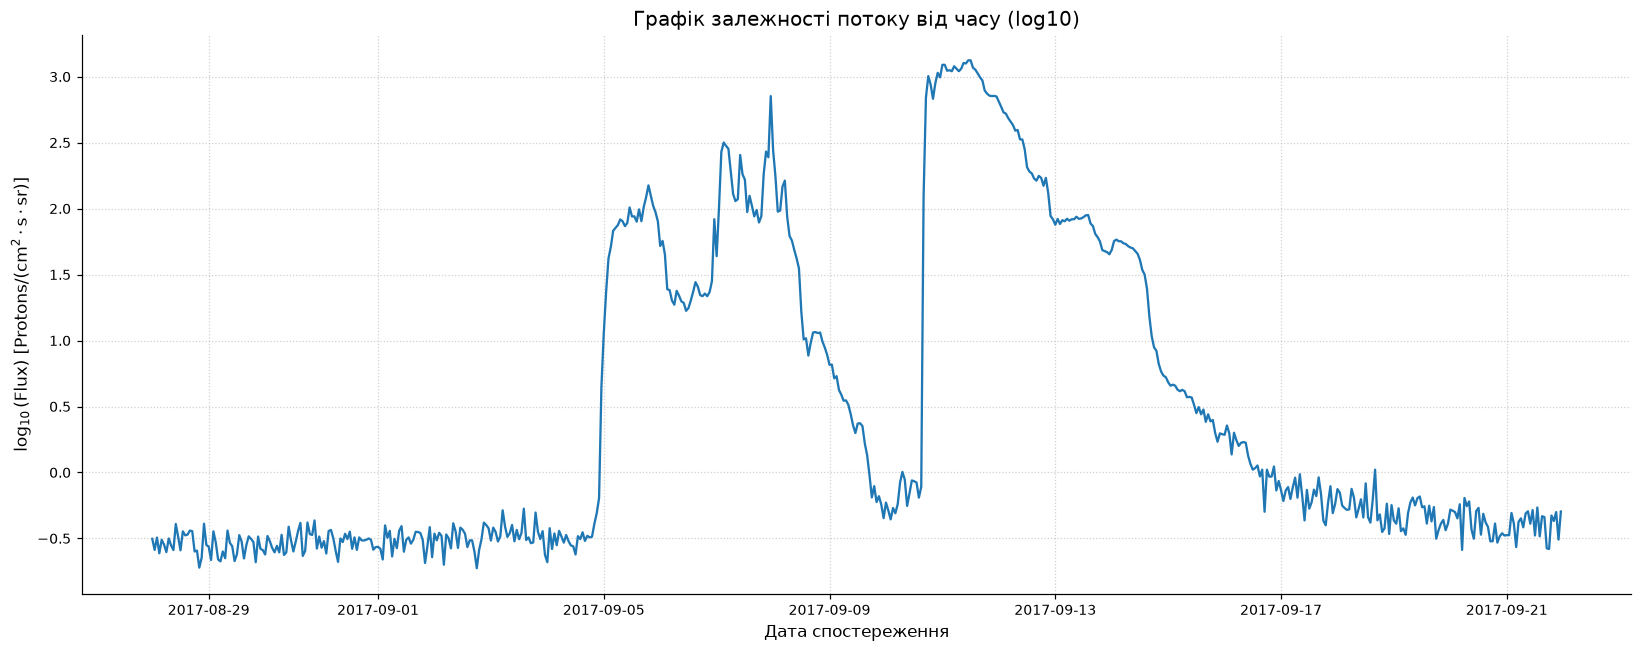

In [ ]:
log_data = np.log10(M['P_gt_10_max'])

fig, ax = plt.subplots(figsize=(15,6))

ax.set_title('Графік залежності потоку від часу (log10)', fontsize=13)
ax.set_xlabel('Дата спостереження', fontsize=11)
# ax.set_ylabel('log10(Потік частинок)', fontsize=11)
ax.set_ylabel(r'$\log_{10}(\text{Flux})$ [$\text{Protons}/(\text{cm}^2 \cdot \text{s} \cdot \text{sr})$]')
ax.grid(True, linestyle=':', alpha=0.6)
ax.plot(M['ts'], log_data)

plt.tight_layout()
plt.show()

**Висновок:**

Значення потоку коливаються в районі 0-1 частинок за годину більшість часу спостереження. З 09.05 по 09.15 відбувся стрибок значень на декілька порядків до максимальних 1000+ частинок за годину.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

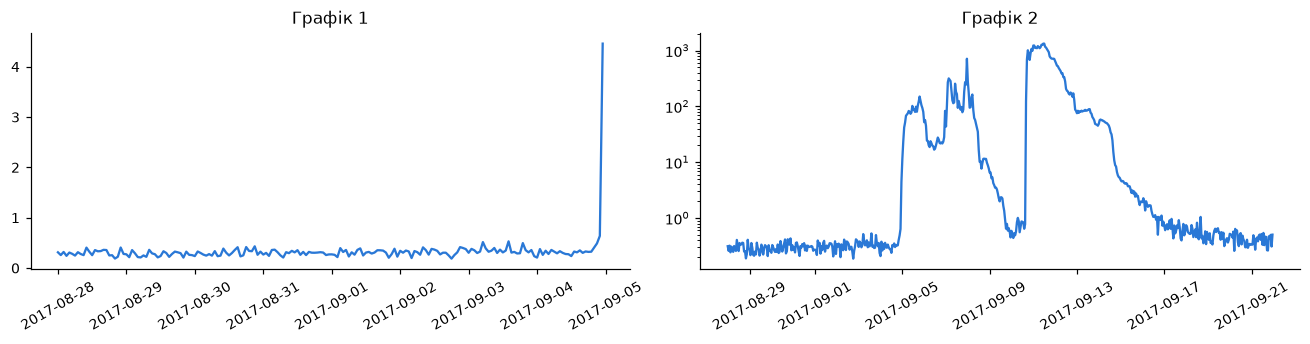

In [129]:
СТОВПЕЦЬ = 'P_gt_10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Людина зробить висновок, що на початку вересня погода була відносно спокійна з сильним сплеском активності приблизно 5 вересня. 
2. Висновок з другого графіка: Людина зробить висновок, що основна активність припадала на дати з 5 вересня до 16-17 вересня, в інші дні активність була помірна. 
3. Дві відмінності між ними: Першою відмінністю є те, що перший графік це короткий відрізок коли активність була низька, а другий графік це повна активністю сонця за весь місяць, тут ми бачимо "всю картину" того що відбувалось за місяць. Другою відмінністю є шкала вимірювання, на першому графіку вона звичайна, а на другому логарифмічна. 


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

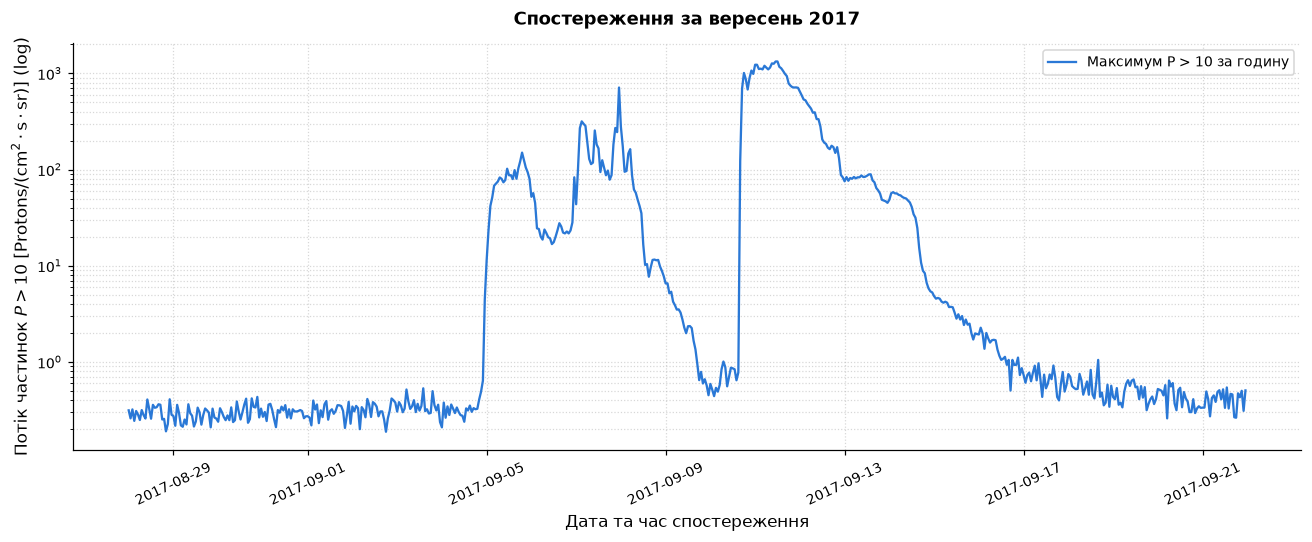

In [135]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(M['ts'], M['P_gt_10_max'], color='#2a78d6', linewidth=1.5, label='Максимум P > 10 за годину')

ax.set_yscale('log')

ax.set_title('Спостереження за вересень 2017', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Дата та час спостереження', fontsize=11)
ax.set_ylabel(r'Потік частинок $P > 10$ [$\text{Protons}/(\text{cm}^2 \cdot \text{s} \cdot \text{sr})$] (log)', fontsize=11)

ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Я вибрав саме такий графік бо тут видно весь час активності сонця і тут я вибрав логарифмічну сітку, щоб було чітко видно перепади графіка на низьких значеннях потоку.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**
В роботі є багато маніпуляцій з часом, але немає ніяких дій з стовпцями таблиці А: "Modified Julian Day" i "Seconds"

**Спостереження 2:**
Різниця медіанного значення і середнього на 1 графіку 5 етапу абсолютно колосальна. Середнє значення в 260 раз більше за медіану.

**Спостереження 3:**
Практична відсутність лінійної кореляції між сонячним вітром і потоком протонів, хоча на перший погляд хоча би мінімальна кореляція мала би бути.



### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [ ]:
missing_ratio = M.isna().any(axis=1).mean()
missing_rows_count = M.isna().any(axis=1).sum()

print(f"Кількість рядків з пропусками: {missing_rows_count} із {len(M)}")
print(f"Частка рядків з пропусками: {missing_ratio:.4f} ({missing_ratio * 100:.2f}%)")


Кількість рядків з пропусками: 8 із 600
Частка рядків з пропусками: 0.0133 (1.33%)


**Відповідь 7.2:**
Частка рядків з пропусками всього приблизно 1%, тобто 8 рядків з 600.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [ ]:
ІНСТРУМЕНТИ_ШІ = ''     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': '',
    'етап 3, паспорт даних і дивні значення':     '',
    'етап 4, об’єднання таблиць':                 '',
    'етап 5, побудова графіків':                  '',
    'етап 5, формулювання висновків':             '',
    'етапи 6–7, порівняння графіків і спостереження': '',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = ''

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = False

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [ ]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

In [ ]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')